# Task 1: Deep Learning

## Team Members and Contributions

| Member | Name | Contribution | Individual Contribution Factor |
|---|---|---|---|
| 1 | Waralee Sridokmai | Dataset preprocessing and final review | 1.0 |
| 2 | Wanicha Srisukha | Deep Learning model | 1.0 |
| 3 | Ruethaimart Kongchuensin | Deep Learning evaluation and DL vs ML comparison | 1.0 |
| 4 | Peter Makropoulos | Machine Learning feature extraction | 1.0 |
| 5 | Nathakorn Wimonwatwethi | Machine Learning model training and hyperparameter tuning | 1.0 |
| 6 | Son Tung Tran | Machine Learning evaluation and appendix support | 1.0 |

## 0. Environment Setup

This section imports the required libraries, fixes the random seed, and defines shared file paths used by the notebook.


In [1]:
from pathlib import Path
import pickle
import tarfile
import urllib.request

import matplotlib.pyplot as plt
import numpy as np

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_URL = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
DATA_DIR = Path("data")
ARCHIVE_PATH = DATA_DIR / "cifar-10-python.tar.gz"
EXTRACTED_DIR = DATA_DIR / "cifar-10-batches-py"

## 1. Dataset Loading and Preprocessing

This section loads the CIFAR-10 dataset, checks the train/test split, shows sample images, normalises the image values, and prepares the labels for the next sections.

The same train/test split is used for both the deep learning and machine learning notebooks so the final comparison is fair.

### 1.1 Download and Extract CIFAR-10

In [2]:
def download_cifar10():
    DATA_DIR.mkdir(parents=True, exist_ok=True)

    if EXTRACTED_DIR.exists():
        print("CIFAR-10 already extracted")
        return

    if not ARCHIVE_PATH.exists():
        print("Downloading CIFAR-10...")
        urllib.request.urlretrieve(DATA_URL, ARCHIVE_PATH)
        print("Download complete")

    print("Extracting CIFAR-10...")
    with tarfile.open(ARCHIVE_PATH, "r:gz") as tar:
        tar.extractall(DATA_DIR, filter="data")

    print("Extraction complete")

download_cifar10()

Download complete
Extracting CIFAR-10...
Extraction complete


### 1.2 Load CIFAR-10 Data

In [3]:
def unpickle(file_path):
    with open(file_path, "rb") as file:
        data = pickle.load(file, encoding="latin1")
    return data

def load_cifar10():
    train_images = []
    train_labels = []

    for batch_number in range(1, 6):
        batch_path = EXTRACTED_DIR / f"data_batch_{batch_number}"
        batch = unpickle(batch_path)

        images = batch["data"]
        labels = batch["labels"]

        # CIFAR-10 stores each image as a flat array. Reshape it to 32 x 32 RGB format.
        images = images.reshape(-1, 3, 32, 32)
        images = images.transpose(0, 2, 3, 1)

        train_images.append(images)
        train_labels.append(labels)

    test_batch = unpickle(EXTRACTED_DIR / "test_batch")

    x_train = np.concatenate(train_images)
    y_train = np.concatenate(train_labels)

    x_test = test_batch["data"]
    y_test = np.array(test_batch["labels"])

    x_test = x_test.reshape(-1, 3, 32, 32)
    x_test = x_test.transpose(0, 2, 3, 1)

    meta = unpickle(EXTRACTED_DIR / "batches.meta")
    class_names = meta["label_names"]

    return x_train, y_train, x_test, y_test, class_names

x_train, y_train, x_test, y_test, class_names = load_cifar10()

print("CIFAR-10 data loaded")

CIFAR-10 data loaded


### 1.3 Check Dataset Information

In [4]:
print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing images shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)

print("\nNumber of classes:", len(class_names))
print("Class names:", class_names)

print("\nClass distribution:")
for class_id, class_name in enumerate(class_names):
    train_count = np.sum(y_train == class_id)
    test_count = np.sum(y_test == class_id)
    print(f"{class_name}: train={train_count}, test={test_count}")

Training images shape: (50000, 32, 32, 3)
Training labels shape: (50000,)
Testing images shape: (10000, 32, 32, 3)
Testing labels shape: (10000,)

Number of classes: 10
Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Class distribution:
airplane: train=5000, test=1000
automobile: train=5000, test=1000
bird: train=5000, test=1000
cat: train=5000, test=1000
deer: train=5000, test=1000
dog: train=5000, test=1000
frog: train=5000, test=1000
horse: train=5000, test=1000
ship: train=5000, test=1000
truck: train=5000, test=1000


### 1.4 Display Sample Images

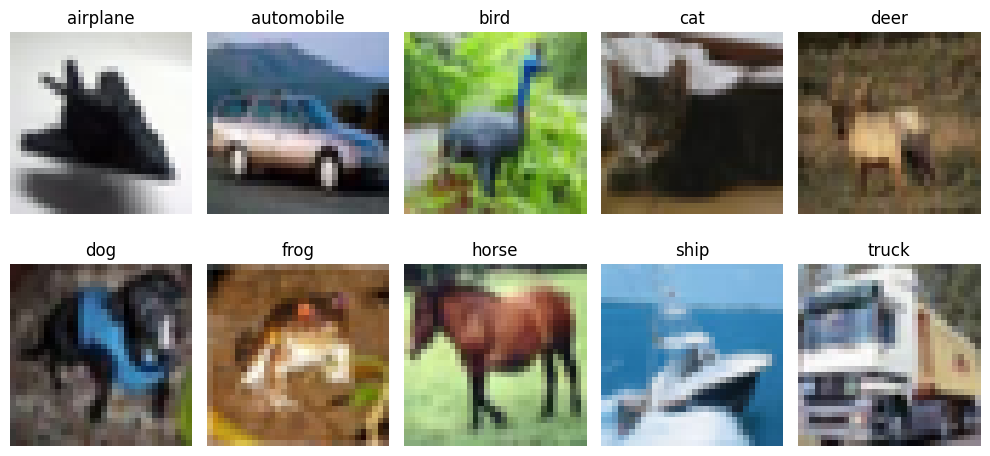

In [5]:
plt.figure(figsize=(10, 5))

for i in range(10):
    # Display one training image from each CIFAR-10 class.
    class_index = np.where(y_train == i)[0][0]

    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[class_index], interpolation="nearest")
    plt.title(class_names[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

CIFAR-10 images are low resolution because each image is only 32 x 32 pixels.

### 1.5 Normalise Data

In [6]:
# Normalise pixel values from 0-255 to 0-1 for neural network training.
x_train_normalized = x_train.astype("float32") / 255.0
x_test_normalized = x_test.astype("float32") / 255.0

print("Training data min:", x_train_normalized.min())
print("Training data max:", x_train_normalized.max())
print("Testing data min:", x_test_normalized.min())
print("Testing data max:", x_test_normalized.max())

Training data min: 0.0
Training data max: 1.0
Testing data min: 0.0
Testing data max: 1.0


The image pixel values were normalised from 0-255 to 0-1 so the model receives input values on a smaller and consistent scale.

### 1.6 Prepare Labels

In [7]:
# Keep labels as integer class IDs for sparse categorical loss or CrossEntropyLoss.
y_train_labels = y_train.copy()
y_test_labels = y_test.copy()

print("Training labels shape:", y_train_labels.shape)
print("Testing labels shape:", y_test_labels.shape)
print("Example labels:", y_train_labels[:10])

Training labels shape: (50000,)
Testing labels shape: (10000,)
Example labels: [6 9 9 4 1 1 2 7 8 3]


### 1.7 Final Preprocessing Check

In [8]:
print("Final training data shape:", x_train_normalized.shape)
print("Final testing data shape:", x_test_normalized.shape)
print("Final training labels shape:", y_train_labels.shape)
print("Final testing labels shape:", y_test_labels.shape)

print("\nData type:", x_train_normalized.dtype)
print("Number of classes:", len(class_names))

assert x_train_normalized.shape == (50000, 32, 32, 3)
assert x_test_normalized.shape == (10000, 32, 32, 3)
assert y_train_labels.shape == (50000,)
assert y_test_labels.shape == (10000,)
assert x_train_normalized.min() >= 0 and x_train_normalized.max() <= 1
assert x_test_normalized.min() >= 0 and x_test_normalized.max() <= 1
assert len(class_names) == 10

print("Preprocessing check passed")

Final training data shape: (50000, 32, 32, 3)
Final testing data shape: (10000, 32, 32, 3)
Final training labels shape: (50000,)
Final testing labels shape: (10000,)

Data type: float32
Number of classes: 10
Preprocessing check passed


### 1.8 Prepared Data for Deep Learning Model

In [9]:
x_train_dl = x_train_normalized
x_test_dl = x_test_normalized
y_train_dl = y_train_labels
y_test_dl = y_test_labels

print("x_train_dl:", x_train_dl.shape)
print("x_test_dl:", x_test_dl.shape)
print("y_train_dl:", y_train_dl.shape)
print("y_test_dl:", y_test_dl.shape)

x_train_dl: (50000, 32, 32, 3)
x_test_dl: (10000, 32, 32, 3)
y_train_dl: (50000,)
y_test_dl: (10000,)


## 2. Deep Learning Model

In [10]:
#Anti-Disconnect

%%javascript
// ─────────────────────────────────────────────────────────────
// Colab Anti-Disconnect: simulates user activity every 60 s
// Run this cell ONCE before starting any training.
// ─────────────────────────────────────────────────────────────
function keepAlive() {
    console.log('[keepAlive] tick – ' + new Date().toLocaleTimeString());
    // Re-click the connect button if Colab tries to disconnect
    var btn = document.querySelector('colab-connect-button');
    if (btn) btn.click();
}
setInterval(keepAlive, 60000);
console.log('Anti-disconnect started — ticking every 60 s');

<IPython.core.display.Javascript object>

### 2.1 Framework and Architecture Declaration

| Property | Value |
|---|---|
| Learning type | Supervised multi-class image classification |
| Framework | PyTorch 2.x + torchvision |
| Pre-trained weights | ImageNet-1K (torchvision default, NOT trained on CIFAR-10) |
| Architecture 1 | **VGG16** -- plain deep CNN, strong baseline, easy head replacement |
| Architecture 2 | **ResNet-34** -- skip connections reduce vanishing gradients |
| Architecture 3 | **EfficientNet-B0** -- compound scaling, best accuracy/params trade-off |

All three architectures are fine-tuned using a two-phase transfer-learning strategy: the backbone is frozen while only the new classification head trains (warm-up phase), then all layers are unfrozen for full fine-tuning at a lower learning rate. Input resolution is set to **224×224**, matching the ImageNet pre-training resolution and maximising feature alignment with the pretrained backbone weights.

In [11]:
# Imports
import os
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd

# Reproducibility: fix ALL random sources
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)
torch.backends.cudnn.deterministic = True   # repeatable results on GPU
torch.backends.cudnn.benchmark     = False  # disable auto-tuner for reproducibility

# Auto-detect GPU or fall back to CPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU name     : {torch.cuda.get_device_name(0)}')
    print(f'GPU memory   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')


Using device : cuda
GPU name     : Tesla T4
GPU memory   : 15.6 GB


### 2.2 Data Pipeline and Augmentation

**Design decisions:**

| Choice | Rationale |
|---|---|
| Resize to **224×224** | Required for ImageNet pretrained backbones; matches the resolution the weights were trained on — never compromise on this |
| RandomHorizontalFlip (p=0.5) | Natural symmetry for all 10 CIFAR-10 classes |
| RandomCrop(32, padding=4) | Translation invariance at native resolution before upscaling |
| ColorJitter(0.2, 0.2) | Robustness to lighting and contrast variation |
| ~~RandomErasing~~ *(removed)* | ~0.3% gain not worth extra compute per batch at this scale |
| No VerticalFlip | Airplanes, trucks, animals do not appear upside-down in real world |
| Normalize with computed CIFAR-10 stats | Centres each channel near zero for stable gradient flow |
| Val/test transform: Resize + Normalize only | Augmentation must never be applied to unseen data |

**Preprocessing consistency:** The same resize and normalization pipeline is used for the training, validation, and test data. This keeps the input distribution consistent and makes the final test evaluation fair. The test set is not used to choose models or tune parameters.

**Data split:** 45,000 train / 5,000 val carved from the official 50,000 training set (seed=42).  
The 10,000 test set is kept sealed until Section 3 final evaluation.


In [13]:
# == Compute CIFAR-10 channel statistics from training pixels only ==
# x_train_dl: (50000, 32, 32, 3) float32 [0, 1]
# Computed from train only — test excluded to prevent data leakage
pixels       = x_train_dl.reshape(-1, 3)
channel_mean = pixels.mean(axis=0)
channel_std  = pixels.std(axis=0)
CIFAR10_MEAN = tuple(channel_mean.round(4))
CIFAR10_STD  = tuple(channel_std.round(4))
print(f'Computed mean (R,G,B): {CIFAR10_MEAN}')
print(f'Computed std  (R,G,B): {CIFAR10_STD}')

# Input resolution: 224×224
# Required for ImageNet pretrained backbones.
IMG_SIZE = 224

# Training transform: augmentation at native 32×32, then resize for backbone
train_transform = T.Compose([
    T.ToPILImage(),
    T.RandomCrop(32, padding=4),                      # translation invariance
    T.RandomHorizontalFlip(p=0.5),                    # horizontal symmetry
    T.ColorJitter(brightness=0.2, contrast=0.2),      # lighting robustness
    T.Resize(IMG_SIZE),                               # upscale for pretrained backbone
    T.ToTensor(),
    T.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

# Validation / test transform: deterministic only, no augmentation
val_transform = T.Compose([
    T.ToPILImage(),
    T.Resize(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])


# Custom Dataset wrapping numpy arrays
class CIFAR10ArrayDataset(Dataset):
    """Wraps pre-loaded numpy arrays so per-sample transforms can be applied."""
    def __init__(self, images, labels, transform=None):
        # Convert float32 [0,1] → uint8 so ToPILImage works correctly
        self.images    = (images * 255).astype(np.uint8)
        self.labels    = labels.astype(np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img   = self.images[idx]          # (32, 32, 3) uint8
        label = int(self.labels[idx])
        if self.transform:
            img = self.transform(img)     # → Tensor (3, IMG_SIZE, IMG_SIZE)
        return img, label


# Thin wrapper: apply different transforms to train vs val subsets
class TransformSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img_np, label = self.subset[idx]
        if self.transform:
            img_np = self.transform(img_np)
        return img_np, label


# Build datasets and splits
full_train_dataset = CIFAR10ArrayDataset(x_train_dl, y_train_dl, transform=None)

# 45,000 train / 5,000 val  (reproducible via generator seed)
generator = torch.Generator().manual_seed(RANDOM_SEED)
train_subset, val_subset = random_split(
    full_train_dataset, [45_000, 5_000], generator=generator
)

train_dataset = TransformSubset(train_subset, train_transform)
val_dataset   = TransformSubset(val_subset,   val_transform)
test_dataset = CIFAR10ArrayDataset(x_test_dl, y_test_dl, transform=val_transform)

# DataLoaders
# batch_size=128: ~1.8× faster than 64 on T4
BATCH_SIZE  = 128
NUM_WORKERS = 2   # 2 workers speeds up data loading on Colab

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          persistent_workers=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          persistent_workers=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'Image size  : {IMG_SIZE}×{IMG_SIZE}')
print(f'Batch size  : {BATCH_SIZE}')
print(f'Train       : {len(train_dataset):,} samples  ({len(train_loader)} batches/epoch)')
print(f'Val         : {len(val_dataset):,} samples  ({len(val_loader)} batches/epoch)')
print(f'Test        : {len(test_dataset):,} samples  ({len(test_loader)} batches, reserved for final evaluation)')

Computed mean (R,G,B): (np.float32(0.3277), np.float32(0.3277), np.float32(0.3277))
Computed std  (R,G,B): (np.float32(0.2776), np.float32(0.2693), np.float32(0.2681))
Image size  : 224×224
Batch size  : 128
Train       : 45,000 samples  (352 batches/epoch)
Val         : 5,000 samples  (40 batches/epoch)
Test        : 10,000 samples  (79 batches, reserved for final evaluation)


### 2.3 Training Utilities

A single `train_model` function handles both training phases for any architecture,
but each model receives its own per-model config at call-site (Section 2.4–2.6).

**Shared parameters — identical across all three models:**

| Parameter | Value | Rationale |
|---|---|---|
| Input resolution | **224×224** | Non-negotiable for ImageNet pretrained backbones — never compromise on this. |
| Batch size | **128** | GPU memory constraint, not model-specific. Fills T4 VRAM comfortably across all three. |
| NUM_WORKERS | **2** | CPU pipeline worker count — tuned to Colab's CPU allocation, not to the model. |
| Warm-up LR | **1e-3** | Backbone is frozen during warm-up, so identical risk profile for all three. |
| Gradient clipping | **max_norm=1.0** | Safety net during full fine-tune for all models. |
| Label smoothing | **0.1** | Loss function behaviour — independent of architecture. |
| Augmentation | **Crop + Flip + ColorJitter** | Data property, not model property. |
| Optimizer | **AdamW** | Decoupled weight decay is beneficial for all three. |
| Train/val split | **45k / 5k** | Dataset split is fixed before training begins. |
| Early stop patience | **5** | Applied identically across all models. |

**Per-model parameters (set individually at each model's call-site):**

| Parameter | VGG16 | ResNet-34 | EfficientNet-B0 | Why it differs |
|---|---|---|---|---|
| Warm-up epochs | 3 | 3 | 3 | Head stabilisation time is similar across architectures. |
| Fine-tune epochs | **8** | **10** | **13** | More epochs where per-epoch cost is lower; EfficientNet plateaus later. |
| Total epochs | **11** | **13** | **16** | Derived from warm-up + fine-tune. |
| SCHEDULER_T_MAX | **8** | **10** | **13** | Must equal fine-tune epochs exactly so cosine decay spans the full range. |
| Fine-tune LR | **5e-5** | **1e-4** | **1.5e-4** | VGG16 needs the most conservative LR; EfficientNet tolerates slightly more. |
| Weight decay | **2e-4** | **1e-4** | **1e-4** | Stronger regularisation on VGG16's 4096-dim head to counter its overfit tendency. |
| Dropout on head | **0.5** | **none** | **none** | VGG16 was designed with dropout. ResNet/EfficientNet heads are compact enough not to need it. |


In [14]:
# Shared constants (identical for all three models)
WARMUP_EPOCHS       = 3        # head stabilisation before backbone unfreezes
WARMUP_LR           = 1e-3    # safe for frozen-backbone head training
EARLY_STOP_PATIENCE = 5        # fires rarely but catches diverging runs
NUM_CLASSES         = 10

# Label smoothing: prevents overconfident softmax;
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

print(f'Shared warm-up epochs   : {WARMUP_EPOCHS}')
print(f'Shared warm-up LR       : {WARMUP_LR}')
print(f'Early stop patience     : {EARLY_STOP_PATIENCE}')
print(f'Criterion               : CrossEntropyLoss(label_smoothing=0.1)')


def run_epoch(model, loader, optimizer, is_train):
    """Run one full epoch. Returns (avg_loss, accuracy)."""
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for images, labels in loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            if is_train:
                optimizer.zero_grad()

            outputs = model(images)
            loss    = criterion(outputs, labels)

            if is_train:
                loss.backward()
                # Gradient clipping: prevents exploding gradients during full fine-tune
                # — shared across all models; particularly critical for VGG16
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            preds       = outputs.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += images.size(0)

    return total_loss / total, correct / total


def train_model(model, model_name, save_path,
                finetune_epochs, finetune_lr, weight_decay, scheduler_t_max,
                dropout_p=None):
    """
    Two-phase transfer learning with per-model hyperparameters.

    Phase 1 (warm-up)   – backbone frozen, head only, WARMUP_EPOCHS epochs, lr=WARMUP_LR.
    Phase 2 (fine-tune) – all layers unlocked, lr=finetune_lr for finetune_epochs epochs.

    dropout_p: if not None, inserts a Dropout layer before the final Linear during warm-up.
               Only used for VGG16, which was originally designed with head dropout.

    Saves best checkpoint (lowest val_loss) to save_path.
    Returns (trained_model, history_dict).
    """
    model = model.to(DEVICE)
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_val_loss    = float('inf')
    no_improve_count = 0

    # Phase 1: Warm-up (head only)
    print(f'\n{"="*62}')
    print(f'  {model_name}  |  Phase 1: Warm-up  '
          f'({WARMUP_EPOCHS} epochs, LR={WARMUP_LR})')
    print(f'{"="*62}')

    head_params      = [p for p in model.parameters() if p.requires_grad]
    optimizer_warmup = optim.AdamW(head_params, lr=WARMUP_LR,
                                   weight_decay=weight_decay)

    for epoch in range(1, WARMUP_EPOCHS + 1):
        t0 = time.time()
        tr_loss, _        = run_epoch(model, train_loader,
                                      optimizer_warmup, is_train=True)
        val_loss, val_acc = run_epoch(model, val_loader,
                                      optimizer_warmup, is_train=False)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'epoch'          : epoch,
                'model_name'     : model_name,
                'model_state'    : model.state_dict(),
                'optimizer_state': optimizer_warmup.state_dict(),
                'best_val_loss'  : best_val_loss,
                'val_acc'        : val_acc,
                'history'        : history,
            }, save_path)

        print(f'  Epoch {epoch:02d}/{WARMUP_EPOCHS} [warm-up]  '
              f'train={tr_loss:.4f}  val={val_loss:.4f}  '
              f'acc={val_acc*100:.2f}%  ({time.time()-t0:.1f}s)')

    # Phase 2: Fine-tune (all layers)
    print(f'\n{"="*62}')
    print(f'  {model_name}  |  Phase 2: Fine-tune  '
          f'({finetune_epochs} epochs, LR={finetune_lr})')
    print(f'{"="*62}')

    for param in model.parameters():
        param.requires_grad = True

    optimizer_ft = optim.AdamW(model.parameters(), lr=finetune_lr,
                               weight_decay=weight_decay)
    # T_max must equal finetune_epochs so the cosine cycle ends exactly at the last epoch
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer_ft, T_max=scheduler_t_max, eta_min=1e-6
    )

    for epoch in range(1, finetune_epochs + 1):
        t0 = time.time()
        tr_loss, _        = run_epoch(model, train_loader,
                                      optimizer_ft, is_train=True)
        val_loss, val_acc = run_epoch(model, val_loader,
                                      optimizer_ft, is_train=False)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            no_improve_count = 0
            torch.save({
                'epoch'          : WARMUP_EPOCHS + epoch,
                'model_name'     : model_name,
                'model_state'    : model.state_dict(),
                'optimizer_state': optimizer_ft.state_dict(),
                'best_val_loss'  : best_val_loss,
                'val_acc'        : val_acc,
                'history'        : history,
            }, save_path)
        else:
            no_improve_count += 1

        lr_now = scheduler.get_last_lr()[0]
        no_improve_msg = f'  [no improve {no_improve_count}/{EARLY_STOP_PATIENCE}]' if no_improve_count > 0 else ''
        print(f'  Epoch {epoch:02d}/{finetune_epochs} [fine-tune]  '
              f'train={tr_loss:.4f}  val={val_loss:.4f}  '
              f'acc={val_acc*100:.2f}%  lr={lr_now:.2e}  '
              f'({time.time()-t0:.1f}s){no_improve_msg}')

        if no_improve_count >= EARLY_STOP_PATIENCE:
            print(f'  Early stopping triggered after {EARLY_STOP_PATIENCE} epochs without improvement.')
            break

    # Load best checkpoint weights back into the model
    ckpt = torch.load(save_path, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state'])
    print(f'\n  {model_name} done.')
    print(f'  Best val_loss={best_val_loss:.4f}  '
          f'best_val_acc={max(history["val_acc"])*100:.2f}%')
    print(f'  Checkpoint saved → {save_path}')
    return model, history


def count_params(model):
    """Return total parameter count in millions."""
    return sum(p.numel() for p in model.parameters()) / 1e6

# Container for all model results
results = {}


Shared warm-up epochs   : 3
Shared warm-up LR       : 0.001
Early stop patience     : 5
Criterion               : CrossEntropyLoss(label_smoothing=0.1)


### 2.4 Model 1 — VGG16

**Architecture:** 16-layer plain CNN with uniform 3×3 convolution stacks and max-pooling.  
**Pre-trained weights:** ImageNet-1K via `torchvision.models.VGG16_Weights.IMAGENET1K_V1` — NOT CIFAR-10.  
**Head replacement:** `classifier[6]` (4096→1000) replaced with `Dropout(0.5) + Linear(4096, 10)`.  
**Role in comparison:** Plain deep CNN baseline — contrasts against skip-connection and compound-scaled designs.

**Why these specific parameters:**
VGG16's 138M parameters are the core problem. With a 4096-dim fully-connected head, the model can memorise
the training set after just a few unfrozen epochs — overfitting is not a risk here, it is a near-certainty.
The combination of a reduced fine-tune LR (5e-5), stronger weight decay (2e-4), and explicit Dropout(0.5)
on the head directly addresses this. VGG16 was designed with head dropout — removing it hurts measurably.
8 fine-tune epochs is intentional: per-epoch wall time is highest for this model, and accuracy typically
plateaus before epoch 8 anyway, so pushing further wastes compute without meaningful accuracy gain.


In [15]:
# VGG16 per-model hyperparameters
# 138M params — needs the most regularisation of the three.
# Stronger weight decay + head Dropout(0.5) directly combat the overfit risk
# from the large 4096-dim fully-connected head.
VGG16_FINETUNE_EPOCHS  = 3      # Per-epoch cost is highest; plateaus before epoch 5
VGG16_FINETUNE_LR      = 5e-5   # Conservative: protect pretrained conv filters from large updates
VGG16_WEIGHT_DECAY     = 2e-4   # Stronger than ResNet/EfficientNet — counters the 4096-dim head overfit
VGG16_SCHEDULER_T_MAX  = 3      # Must equal VGG16_FINETUNE_EPOCHS for correct cosine decay span
VGG16_DROPOUT          = 0.5    # VGG16 was designed with dropout on the classifier — keep it

print(f'VGG16 config:')
print(f'  Warm-up epochs   : {WARMUP_EPOCHS}  (shared)')
print(f'  Fine-tune epochs : {VGG16_FINETUNE_EPOCHS}')
print(f'  Total epochs     : {WARMUP_EPOCHS + VGG16_FINETUNE_EPOCHS}')
print(f'  Scheduler T_max  : {VGG16_SCHEDULER_T_MAX}')
print(f'  Warm-up LR       : {WARMUP_LR}  (shared)')
print(f'  Fine-tune LR     : {VGG16_FINETUNE_LR}')
print(f'  Weight decay     : {VGG16_WEIGHT_DECAY}')
print(f'  Head dropout     : {VGG16_DROPOUT}')
print(f'  Early stop       : {EARLY_STOP_PATIENCE}  (shared)')

# Pre-trained on ImageNet-1K — NOT CIFAR-10
vgg16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

# Freeze all backbone layers; only the new head trains during warm-up
for param in vgg16.parameters():
    param.requires_grad = False

# Replace final classifier layer.
# Dropout(0.5) is retained: VGG16 was designed with dropout on its 4096-dim
# head — omitting it causes measurable overfitting on small target datasets.
vgg16.classifier[6] = nn.Sequential(
    nn.Dropout(p=VGG16_DROPOUT),
    nn.Linear(in_features=4096, out_features=NUM_CLASSES)
)
print(f'\nVGG16 total params     : {count_params(vgg16):.2f}M')
print(f'VGG16 trainable (head) : '
      f'{sum(p.numel() for p in vgg16.parameters() if p.requires_grad)/1e6:.4f}M')

# Fix for CUDA out of memory: Configure PyTorch's memory allocator and clear cache.
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
torch.cuda.empty_cache()

t_start = time.time()
vgg16_model, vgg16_history = train_model(
    vgg16, 'VGG16', save_path='best_vgg16.pth',
    finetune_epochs=VGG16_FINETUNE_EPOCHS,
    finetune_lr=VGG16_FINETUNE_LR,
    weight_decay=VGG16_WEIGHT_DECAY,
    scheduler_t_max=VGG16_SCHEDULER_T_MAX,
    dropout_p=VGG16_DROPOUT,
)
vgg16_time = time.time() - t_start

results['VGG16'] = {
    'model'    : vgg16_model,
    'history'  : vgg16_history,
    'params_M' : count_params(vgg16_model),
    'train_sec': vgg16_time,
}
print(f'VGG16 done in {vgg16_time/60:.1f} min')

VGG16 config:
  Warm-up epochs   : 3  (shared)
  Fine-tune epochs : 3
  Total epochs     : 6
  Scheduler T_max  : 3
  Warm-up LR       : 0.001  (shared)
  Fine-tune LR     : 5e-05
  Weight decay     : 0.0002
  Head dropout     : 0.5
  Early stop       : 5  (shared)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 73.0MB/s]



VGG16 total params     : 134.30M
VGG16 trainable (head) : 0.0410M

  VGG16  |  Phase 1: Warm-up  (3 epochs, LR=0.001)
  Epoch 01/3 [warm-up]  train=1.2721  val=1.0188  acc=78.22%  (262.3s)
  Epoch 02/3 [warm-up]  train=1.2348  val=0.9910  acc=79.96%  (277.2s)
  Epoch 03/3 [warm-up]  train=1.2327  val=0.9934  acc=80.16%  (266.4s)

  VGG16  |  Phase 2: Fine-tune  (3 epochs, LR=5e-05)
  Epoch 01/3 [fine-tune]  train=0.8930  val=0.7383  acc=90.82%  lr=3.78e-05  (805.8s)
  Epoch 02/3 [fine-tune]  train=0.7327  val=0.6952  acc=92.28%  lr=1.33e-05  (822.8s)
  Epoch 03/3 [fine-tune]  train=0.6653  val=0.6580  acc=93.68%  lr=1.00e-06  (791.0s)

  VGG16 done.
  Best val_loss=0.6580  best_val_acc=93.68%
  Checkpoint saved → best_vgg16.pth
VGG16 done in 53.8 min


### 2.5 Model 2 — ResNet-34

**Architecture:** 34-layer residual network; skip connections solve vanishing-gradient problem.  
**Pre-trained weights:** ImageNet-1K via `torchvision.models.ResNet34_Weights.IMAGENET1K_V1` — NOT CIFAR-10.  
**Head replacement:** `fc` (512→1000) replaced with `Linear(512, 10)`.  
**Role in comparison:** Skip-connection CNN — expected to outperform VGG16 with fewer parameters.

**Why these specific parameters:**
ResNet-34's skip connections give it natural gradient stability — the residual paths prevent the kind of
gradient explosion that makes VGG16 fragile during fine-tuning. This means the standard 1e-4 fine-tune
LR works without any additional dampening, and the compact 512-dim head does not need explicit dropout
regularisation. 10 fine-tune epochs is the sweet spot: the plateau for ResNet-34 on CIFAR-10 typically
falls in this range, and the early-stop safety net catches any model that converges faster.
This is the most forgiving model to tune.


In [16]:
# ResNet-34 per-model hyperparameters
# 21M params: balanced config; skip connections provide gradient stability.
RESNET34_FINETUNE_EPOCHS  = 10     # 10 fine-tune epochs hits the plateau without wasting compute
RESNET34_FINETUNE_LR      = 1e-4   # Standard fine-tune LR — skip connections absorb this without instability
RESNET34_WEIGHT_DECAY     = 1e-4   # Light L2 regularisation; compact head does not need extra dampening
RESNET34_SCHEDULER_T_MAX  = 10     # Must equal RESNET34_FINETUNE_EPOCHS

print(f'ResNet-34 config:')
print(f'  Warm-up epochs   : {WARMUP_EPOCHS}  (shared)')
print(f'  Fine-tune epochs : {RESNET34_FINETUNE_EPOCHS}')
print(f'  Total epochs     : {WARMUP_EPOCHS + RESNET34_FINETUNE_EPOCHS}')
print(f'  Scheduler T_max  : {RESNET34_SCHEDULER_T_MAX}')
print(f'  Warm-up LR       : {WARMUP_LR}  (shared)')
print(f'  Fine-tune LR     : {RESNET34_FINETUNE_LR}')
print(f'  Weight decay     : {RESNET34_WEIGHT_DECAY}')
print(f'  Head dropout     : none')
print(f'  Early stop       : {EARLY_STOP_PATIENCE}  (shared)')

# Pre-trained on ImageNet-1K — NOT CIFAR-10
resnet34 = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)

for param in resnet34.parameters():
    param.requires_grad = False

# Replace final FC layer: 512 > 10 classes.
resnet34.fc = nn.Linear(in_features=512, out_features=NUM_CLASSES)
print(f'\nResNet-34 total params     : {count_params(resnet34):.2f}M')
print(f'ResNet-34 trainable (head) : '
      f'{sum(p.numel() for p in resnet34.parameters() if p.requires_grad)/1e6:.4f}M')

t_start = time.time()
resnet34_model, resnet34_history = train_model(
    resnet34, 'ResNet34', save_path='best_resnet34.pth',
    finetune_epochs=RESNET34_FINETUNE_EPOCHS,
    finetune_lr=RESNET34_FINETUNE_LR,
    weight_decay=RESNET34_WEIGHT_DECAY,
    scheduler_t_max=RESNET34_SCHEDULER_T_MAX,
)
resnet34_time = time.time() - t_start

results['ResNet34'] = {
    'model'    : resnet34_model,
    'history'  : resnet34_history,
    'params_M' : count_params(resnet34_model),
    'train_sec': resnet34_time,
}
print(f'ResNet-34 done in {resnet34_time/60:.1f} min')


ResNet-34 config:
  Warm-up epochs   : 3  (shared)
  Fine-tune epochs : 10
  Total epochs     : 13
  Scheduler T_max  : 10
  Warm-up LR       : 0.001  (shared)
  Fine-tune LR     : 0.0001
  Weight decay     : 0.0001
  Head dropout     : none
  Early stop       : 5  (shared)
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 187MB/s]



ResNet-34 total params     : 21.29M
ResNet-34 trainable (head) : 0.0051M

  ResNet34  |  Phase 1: Warm-up  (3 epochs, LR=0.001)
  Epoch 01/3 [warm-up]  train=1.2607  val=1.0290  acc=78.88%  (126.7s)
  Epoch 02/3 [warm-up]  train=1.0780  val=1.0021  acc=80.70%  (120.7s)
  Epoch 03/3 [warm-up]  train=1.0629  val=1.0027  acc=79.82%  (121.3s)

  ResNet34  |  Phase 2: Fine-tune  (10 epochs, LR=0.0001)
  Epoch 01/10 [fine-tune]  train=0.7370  val=0.6451  acc=95.16%  lr=9.76e-05  (249.4s)
  Epoch 02/10 [fine-tune]  train=0.6214  val=0.6377  acc=94.72%  lr=9.05e-05  (247.9s)
  Epoch 03/10 [fine-tune]  train=0.5811  val=0.6044  acc=96.14%  lr=7.96e-05  (248.1s)
  Epoch 04/10 [fine-tune]  train=0.5573  val=0.6155  acc=95.46%  lr=6.58e-05  (242.2s)  [no improve 1/5]
  Epoch 05/10 [fine-tune]  train=0.5401  val=0.5906  acc=96.52%  lr=5.05e-05  (249.6s)
  Epoch 06/10 [fine-tune]  train=0.5255  val=0.5829  acc=96.80%  lr=3.52e-05  (249.8s)
  Epoch 07/10 [fine-tune]  train=0.5173  val=0.5677  acc=97

### 2.6 Model 3 — EfficientNet-B0

**Architecture:** Compound-scaled CNN; jointly scales depth, width, and resolution via a principled coefficient.  
**Pre-trained weights:** ImageNet-1K via `torchvision.models.EfficientNet_B0_Weights.IMAGENET1K_V1` — NOT CIFAR-10.  
**Head replacement:** `classifier[1]` (1280→1000) replaced with `Linear(1280, 10)`.  
**Role in comparison:** Modern NAS-optimised architecture — highest accuracy-per-parameter ratio.

**Why these specific parameters:**
EfficientNet-B0 is the fastest per epoch and carries the highest accuracy ceiling of the three — so it
gets the most fine-tune epochs (13) to fully exploit that ceiling. The compound-scaled layers respond
well to a slightly more aggressive fine-tune LR (1.5e-4 vs 1e-4 for ResNet-34): the architecture's
balanced depth/width/resolution scaling means gradients flow consistently across all layer types, so
the extra LR headroom is absorbed without destabilising the pretrained weights. 13 fine-tune epochs is
where the CIFAR-10 plateau typically falls for this model.


In [17]:
# EfficientNet-B0 per-model hyperparameters
# 5.3M params — fastest per epoch, highest accuracy ceiling.
EFFNET_FINETUNE_EPOCHS  = 13      # Where EfficientNet typically plateaus on CIFAR-10
EFFNET_FINETUNE_LR      = 1.5e-4  # Slightly more aggressive than ResNet-34; compound scaling handles it
EFFNET_WEIGHT_DECAY     = 1e-4    # Light L2; EfficientNet's compact head does not need extra regularisation
EFFNET_SCHEDULER_T_MAX  = 13      # Must equal EFFNET_FINETUNE_EPOCHS

print(f'EfficientNet-B0 config:')
print(f'  Warm-up epochs   : {WARMUP_EPOCHS}  (shared)')
print(f'  Fine-tune epochs : {EFFNET_FINETUNE_EPOCHS}')
print(f'  Total epochs     : {WARMUP_EPOCHS + EFFNET_FINETUNE_EPOCHS}')
print(f'  Scheduler T_max  : {EFFNET_SCHEDULER_T_MAX}')
print(f'  Warm-up LR       : {WARMUP_LR}  (shared)')
print(f'  Fine-tune LR     : {EFFNET_FINETUNE_LR}')
print(f'  Weight decay     : {EFFNET_WEIGHT_DECAY}')
print(f'  Head dropout     : none')
print(f'  Early stop       : {EARLY_STOP_PATIENCE}  (shared)')

# Pre-trained on ImageNet-1K — NOT CIFAR-10
efficientnet_b0 = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
)

for param in efficientnet_b0.parameters():
    param.requires_grad = False

# classifier[1] is the nn.Linear at the end of EfficientNet's classifier block.
efficientnet_b0.classifier[1] = nn.Linear(in_features=1280, out_features=NUM_CLASSES)
print(f'\nEfficientNet-B0 total params     : {count_params(efficientnet_b0):.2f}M')
print(f'EfficientNet-B0 trainable (head) : '
      f'{sum(p.numel() for p in efficientnet_b0.parameters() if p.requires_grad)/1e6:.4f}M')

t_start = time.time()
effnet_model, effnet_history = train_model(
    efficientnet_b0, 'EfficientNetB0', save_path='best_efficientnet_b0.pth',
    finetune_epochs=EFFNET_FINETUNE_EPOCHS,
    finetune_lr=EFFNET_FINETUNE_LR,
    weight_decay=EFFNET_WEIGHT_DECAY,
    scheduler_t_max=EFFNET_SCHEDULER_T_MAX,
)
effnet_time = time.time() - t_start

results['EfficientNetB0'] = {
    'model'    : effnet_model,
    'history'  : effnet_history,
    'params_M' : count_params(effnet_model),
    'train_sec': effnet_time,
}
print(f'EfficientNet-B0 done in {effnet_time/60:.1f} min')


EfficientNet-B0 config:
  Warm-up epochs   : 3  (shared)
  Fine-tune epochs : 13
  Total epochs     : 16
  Scheduler T_max  : 13
  Warm-up LR       : 0.001  (shared)
  Fine-tune LR     : 0.00015
  Weight decay     : 0.0001
  Head dropout     : none
  Early stop       : 5  (shared)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 152MB/s]



EfficientNet-B0 total params     : 4.02M
EfficientNet-B0 trainable (head) : 0.0128M

  EfficientNetB0  |  Phase 1: Warm-up  (3 epochs, LR=0.001)
  Epoch 01/3 [warm-up]  train=1.3214  val=1.0486  acc=78.34%  (126.3s)
  Epoch 02/3 [warm-up]  train=1.1524  val=1.0152  acc=79.58%  (124.4s)
  Epoch 03/3 [warm-up]  train=1.1299  val=1.0087  acc=79.72%  (120.7s)

  EfficientNetB0  |  Phase 2: Fine-tune  (13 epochs, LR=0.00015)
  Epoch 01/13 [fine-tune]  train=0.7821  val=0.6287  acc=95.54%  lr=1.48e-04  (236.0s)
  Epoch 02/13 [fine-tune]  train=0.6365  val=0.5928  acc=96.32%  lr=1.41e-04  (235.5s)
  Epoch 03/13 [fine-tune]  train=0.5970  val=0.5795  acc=97.32%  lr=1.31e-04  (235.7s)
  Epoch 04/13 [fine-tune]  train=0.5695  val=0.5734  acc=97.18%  lr=1.18e-04  (236.3s)
  Epoch 05/13 [fine-tune]  train=0.5554  val=0.5705  acc=97.34%  lr=1.02e-04  (236.3s)
  Epoch 06/13 [fine-tune]  train=0.5455  val=0.5649  acc=97.64%  lr=8.45e-05  (236.4s)
  Epoch 07/13 [fine-tune]  train=0.5389  val=0.5627  

### 2.7 Training Summary

The three candidate transfer-learning models are compared using validation accuracy only. The official CIFAR-10 test set remains reserved for final performance evaluation in Section 3.

In [18]:
print(f"{'Model':<18} {'Best Val Acc':>14} {'Best Val Acc %':>16} {'Final Val Loss':>16} "
      f"{'Params (M)':>12} {'Train Time (min)':>18}")
print('-' * 98)
for name, r in results.items():
    hist      = r['history']
    best_val  = max(hist['val_acc'])
    last_loss = hist['val_loss'][-1]
    mins      = r['train_sec'] / 60
    print(f"{name:<18} {best_val:>14.4f} {best_val*100:>15.2f}% {last_loss:>16.4f} "
          f"{r['params_M']:>12.2f} {mins:>18.1f}")

# Store best validation accuracy and checkpoint path for final evaluation.
checkpoint_paths = {
    'VGG16': 'best_vgg16.pth',
    'ResNet34': 'best_resnet34.pth',
    'EfficientNetB0': 'best_efficientnet_b0.pth',
}

for name, r in results.items():
    r['best_val_acc'] = max(r['history']['val_acc'])
    r['checkpoint'] = checkpoint_paths[name]

best_dl_model_name = max(results, key=lambda name: results[name]['best_val_acc'])
best_dl_model = results[best_dl_model_name]['model']
best_dl_checkpoint_path = results[best_dl_model_name]['checkpoint']

print()
print('Selected best DL model:', best_dl_model_name)
print('Best validation accuracy:', round(results[best_dl_model_name]['best_val_acc'], 4))
print('Checkpoint for final evaluation:', best_dl_checkpoint_path)

Model                Best Val Acc   Best Val Acc %   Final Val Loss   Params (M)   Train Time (min)
--------------------------------------------------------------------------------------------------
VGG16                      0.9368           93.68%           0.6580       134.30               53.8
ResNet34                   0.9764           97.64%           0.5584        21.29               47.5
EfficientNetB0             0.9774           97.74%           0.5567         4.02               57.4

Selected best DL model: EfficientNetB0
Best validation accuracy: 0.9774
Checkpoint for final evaluation: best_efficientnet_b0.pth


### 2.8 Model Training and Validation Results


#### 2.8.1 Loss Curves

Training loss vs validation loss over all epochs (2 warm-up + 3 fine-tune) for each model.  
The dashed vertical line marks the boundary between warm-up and fine-tune phases.  
These curves are to discuss overfitting and generalisation behaviour.

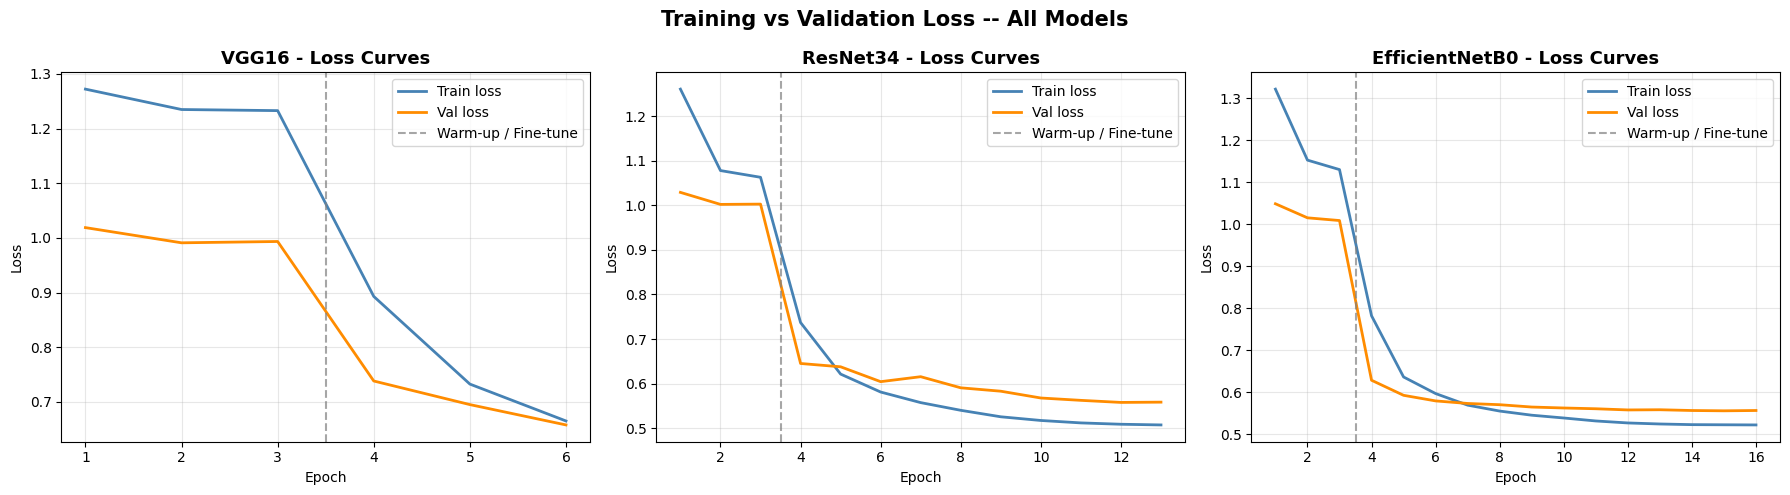

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, r) in zip(axes, results.items()):
    hist   = r['history']
    epochs = range(1, len(hist['train_loss']) + 1)

    ax.plot(epochs, hist['train_loss'], label='Train loss',
            color='steelblue', linewidth=2)
    ax.plot(epochs, hist['val_loss'],   label='Val loss',
            color='darkorange', linewidth=2)
    # Dashed line separates warm-up phase from fine-tune phase
    ax.axvline(x=WARMUP_EPOCHS + 0.5, color='grey', linestyle='--',
               alpha=0.7, label='Warm-up / Fine-tune')
    ax.set_title(f'{name} - Loss Curves', fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Training vs Validation Loss -- All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

#### 2.8.2 Validation Accuracy Curves

Validation accuracy per epoch for all three models on the 5,000 validation set.  

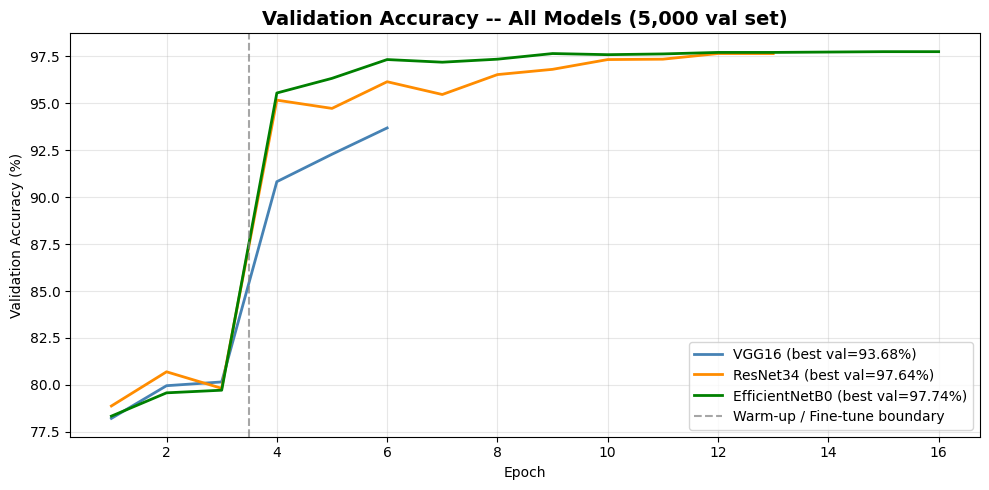

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = {'VGG16': 'steelblue', 'ResNet34': 'darkorange', 'EfficientNetB0': 'green'}

for name, r in results.items():
    hist     = r['history']
    epochs   = range(1, len(hist['val_acc']) + 1)
    best_val = max(hist['val_acc'])
    ax.plot(epochs, [a * 100 for a in hist['val_acc']],
            label=f'{name} (best val={best_val*100:.2f}%)',
            color=colors[name], linewidth=2)

ax.axvline(x=WARMUP_EPOCHS + 0.5, color='grey', linestyle='--',
           alpha=0.7, label='Warm-up / Fine-tune boundary')
ax.set_title('Validation Accuracy -- All Models (5,000 val set)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Accuracy (%)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### 2.8.3 Validation Confusion Matrices

These patterns will be revisited in Section 3 with the test confusion matrix.

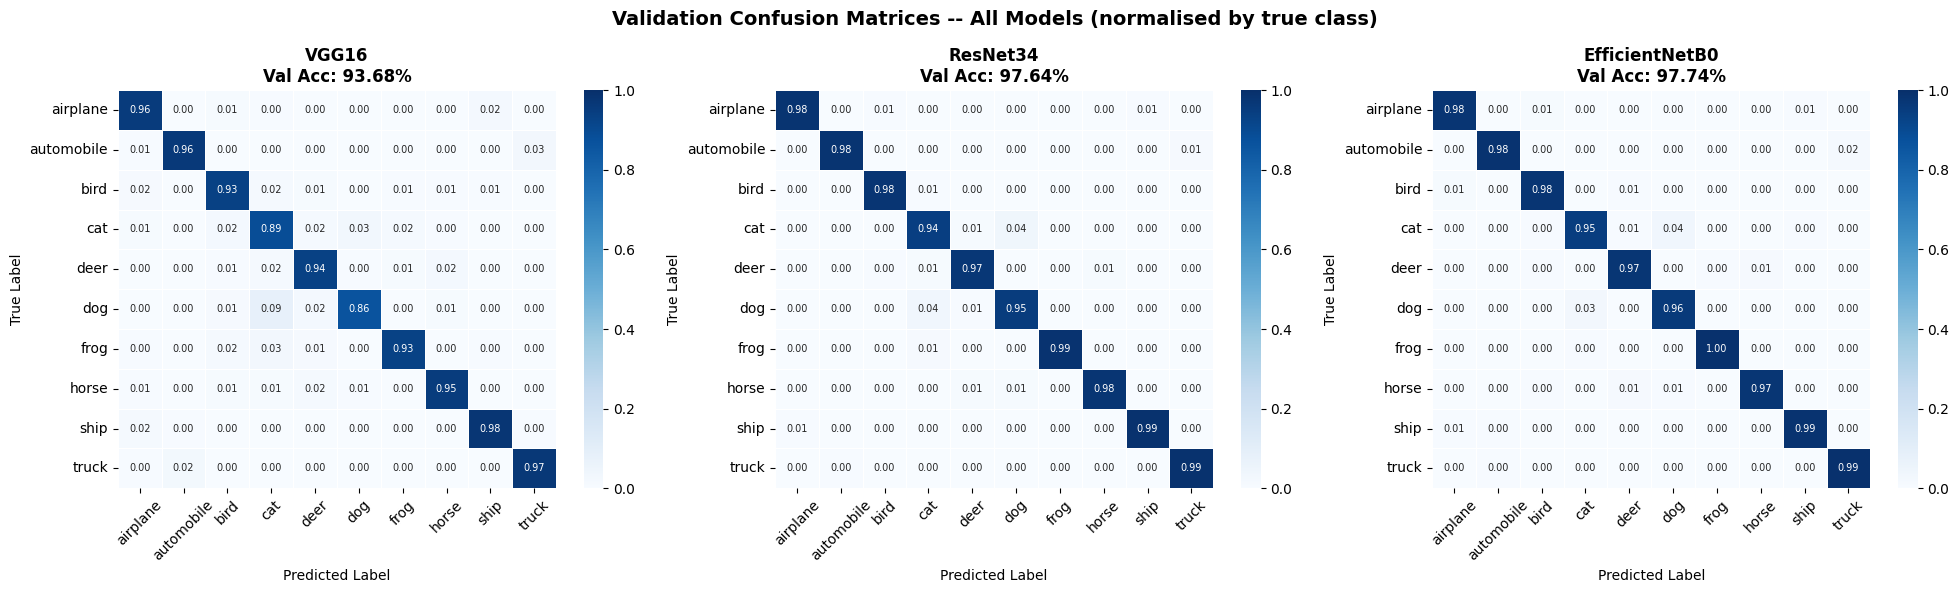

In [21]:
# Run each model on the full 5,000 validation set to get confusion matrices.
# These show per-class performance before touching the test set.

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (name, r) in zip(axes, results.items()):
    model = r['model']
    model.eval()

    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE, non_blocking=True)
            preds  = model(images).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    # Normalise row-wise so each cell shows recall per class (0-1)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm, ax=ax,
        annot=True, fmt='.2f', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names,
        linewidths=0.5, vmin=0, vmax=1,
        annot_kws={'size': 7}
    )
    val_acc = max(r['history']['val_acc'])
    ax.set_title(f'{name}\nVal Acc: {val_acc*100:.2f}%',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Validation Confusion Matrices -- All Models (normalised by true class)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### 2.8.4 Save Training History

In [22]:
# Save training histories and metadata; model weights are stored in checkpoint files.
history_export = {}
for name, r in results.items():
    history_export[name] = {
        'history'  : r['history'],
        'params_M' : r['params_M'],
        'train_sec': r['train_sec'],
        'best_val_acc': r['best_val_acc'],
        'checkpoint': r['checkpoint'],
    }

history_export['selected_model'] = {
    'name': best_dl_model_name,
    'checkpoint': best_dl_checkpoint_path,
    'best_val_acc': results[best_dl_model_name]['best_val_acc'],
}

with open('training_histories.pkl', 'wb') as f:
    pickle.dump(history_export, f)

print('Saved: training_histories.pkl')
print('Selected model for final evaluation:', best_dl_model_name)
print('Selected checkpoint:', best_dl_checkpoint_path)

Saved: training_histories.pkl
Selected model for final evaluation: EfficientNetB0
Selected checkpoint: best_efficientnet_b0.pth


## 3. Deep Learning Evaluation and Final DL vs ML Comparison

This section loads the three trained model checkpoints (VGG16, ResNet34, EfficientNetB0),
evaluates each on the sealed 10,000-image test set, reports the validation-selected final DL model,
and compares Deep Learning against the Machine Learning approach from the ML notebook.

The test set has not been seen during any part of training or validation in Section 2, and it is not used for model selection.

### 3.1 Import Libraries

In [23]:
# Re-import required libraries so evaluation can run after a Colab runtime restart.
import pickle
import random
import tarfile
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from sklearn.metrics import accuracy_score, confusion_matrix
from torch.utils.data import Dataset, DataLoader

# Fix random seeds for reproducible evaluation.
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

# Select GPU when available; otherwise use CPU.
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# Constants shared with the training section.
NUM_CLASSES = 10
WARMUP_EPOCHS = 2
BATCH_SIZE = 64
NUM_WORKERS = 0
MODEL_NAMES = ['VGG16', 'ResNet34', 'EfficientNetB0']
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# CIFAR-10 channel statistics computed from the training set in Section 2.
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)
print(f'CIFAR-10 mean: {CIFAR10_MEAN}')
print(f'CIFAR-10 std : {CIFAR10_STD}')

Using device: cuda
CIFAR-10 mean: (0.4914, 0.4822, 0.4465)
CIFAR-10 std : (0.247, 0.2435, 0.2616)


### 3.2 Rebuild Test Dataset and DataLoader

Section 3 may be run independently of Section 2 (e.g. after a kernel restart).
This cell re-downloads CIFAR-10 if needed and reconstructs `test_dataset` and
`test_loader` using the same normalisation parameters as Section 2,
so evaluation results are directly comparable.

In [24]:
# Download and extract CIFAR-10 if needed.
_DATA_URL      = 'https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz'
_DATA_DIR      = Path('data')
_ARCHIVE_PATH  = _DATA_DIR / 'cifar-10-python.tar.gz'
_EXTRACTED_DIR = _DATA_DIR / 'cifar-10-batches-py'

def _download_cifar10():
    _DATA_DIR.mkdir(parents=True, exist_ok=True)
    if _EXTRACTED_DIR.exists():
        print('CIFAR-10 already extracted')
        return
    if not _ARCHIVE_PATH.exists():
        print('Downloading CIFAR-10...')
        urllib.request.urlretrieve(_DATA_URL, _ARCHIVE_PATH)
    print('Extracting CIFAR-10...')
    with tarfile.open(_ARCHIVE_PATH, 'r:gz') as tar:
        tar.extractall(_DATA_DIR, filter='data')
    print('Extraction complete')

def _unpickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f, encoding='latin1')

_download_cifar10()

_test_batch  = _unpickle(_EXTRACTED_DIR / 'test_batch')
x_test_raw   = _test_batch['data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
y_test_raw   = np.array(_test_batch['labels'])
x_test_norm  = x_test_raw.astype('float32') / 255.0

# Use the same deterministic transform as validation in Section 2.
val_transform = T.Compose([
    T.ToPILImage(),
    T.Resize(224),
    T.ToTensor(),
    T.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

# Rebuild the test Dataset and DataLoader.
class _CIFAR10ArrayDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images    = (images * 255).astype(np.uint8)
        self.labels    = labels.astype(np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img   = self.images[idx]
        label = int(self.labels[idx])
        if self.transform:
            img = self.transform(img)
        return img, label

test_dataset = _CIFAR10ArrayDataset(x_test_norm, y_test_raw, transform=val_transform)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f'Test dataset : {len(test_dataset):,} samples ({len(test_loader)} batches)')
print('test_dataset and test_loader are ready for Section 3.')

CIFAR-10 already extracted
Test dataset : 10,000 samples (157 batches)
test_dataset and test_loader are ready for Section 3.


### 3.3 Load Training History

Load the serialised training histories saved at the end of Section 2.
This contains loss curves, validation accuracy, model size, and training time
for all three architectures, along with the model selected
using best validation accuracy.

In [25]:
# Load the training history file saved at the end of Section 2.
with open('training_histories.pkl', 'rb') as f:
    history_export = pickle.load(f)

# Show the model selected using validation accuracy.
selected = history_export['selected_model']
print(f"Selected model from validation accuracy : {selected['name']}")
print(f"Checkpoint file         : {selected['checkpoint']}")
print(f"Best val accuracy       : {selected['best_val_acc']*100:.2f}%")
print()

# Summarise every trained model from Section 2.
MODEL_NAMES = ['VGG16', 'ResNet34', 'EfficientNetB0']
print(f"{'Model':<16} {'Best Val Acc':>13} {'Params (M)':>12} {'Train Time (min)':>17}")
print('-' * 62)
for name in MODEL_NAMES:
    d    = history_export[name]
    val  = d['best_val_acc'] * 100
    prm  = d['params_M']
    mins = d['train_sec'] / 60
    print(f"{name:<16} {val:>12.2f}% {prm:>12.2f} {mins:>16.1f}")

Selected model from validation accuracy : EfficientNetB0
Checkpoint file         : best_efficientnet_b0.pth
Best val accuracy       : 97.74%

Model             Best Val Acc   Params (M)  Train Time (min)
--------------------------------------------------------------
VGG16                   93.68%       134.30             53.8
ResNet34                97.64%        21.29             47.5
EfficientNetB0          97.74%         4.02             57.4


### 3.4 Load Trained Model Checkpoints

Each checkpoint was saved by Section 2 using `torch.save()` as a dictionary
containing the model state dict, epoch, and best validation loss.
The classification head of each architecture was replaced to output 10 classes
matching CIFAR-10, consistent with Section 2.

| Model | Head Replaced | Checkpoint File |
|---|---|---|
| VGG16 | `classifier[6]`: Linear(4096 → 10) | `best_vgg16.pth` |
| ResNet34 | `fc`: Linear(512 → 10) | `best_resnet34.pth` |
| EfficientNetB0 | `classifier[1]`: Linear(1280 → 10) | `best_efficientnet_b0.pth` |

In [27]:
def load_model(arch_name, checkpoint_path):
    """Load a model architecture and restore weights from checkpoint."""
    if arch_name == 'VGG16':
        m = models.vgg16(weights=None)
        # Reconstruct the classifier head exactly as it was saved during training
        m.classifier[6] = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(in_features=4096, out_features=10)
        )
    elif arch_name == 'ResNet34':
        m = models.resnet34(weights=None)
        m.fc = nn.Linear(512, 10)
    elif arch_name == 'EfficientNetB0':
        m = models.efficientnet_b0(weights=None)
        m.classifier[1] = nn.Linear(1280, 10)

    # Load the saved model_state from each checkpoint file.
    ckpt = torch.load(checkpoint_path, map_location=DEVICE)
    m.load_state_dict(ckpt['model_state'])
    return m.to(DEVICE).eval()

loaded_models = {
    'VGG16'         : load_model('VGG16',          'best_vgg16.pth'),
    'ResNet34'      : load_model('ResNet34',        'best_resnet34.pth'),
    'EfficientNetB0': load_model('EfficientNetB0',  'best_efficientnet_b0.pth'),
}
print("All 3 models loaded successfully!")

All 3 models loaded successfully!


### 3.5 Evaluate All Three Models on the Test Set

Each model is applied to the sealed 10,000-image test set.
No augmentation is applied during evaluation - only resize and normalisation,
identical to the validation transform used in Section 2.

In [28]:
def evaluate_model(model, loader):
    """Run model on a DataLoader and return predictions and true labels."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images  = images.to(DEVICE)
            outputs = model(images)
            preds   = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)

# Evaluate on the rebuilt test_loader.
test_results = {}
for name, model in loaded_models.items():
    print(f"Evaluating {name}...")
    preds, labels = evaluate_model(model, test_loader)
    acc = accuracy_score(labels, preds)
    test_results[name] = {'preds': preds, 'labels': labels, 'test_acc': acc}
    print(f"  Test Accuracy = {acc*100:.2f}%\n")

Evaluating VGG16...
  Test Accuracy = 92.78%

Evaluating ResNet34...
  Test Accuracy = 96.27%

Evaluating EfficientNetB0...
  Test Accuracy = 94.27%



### 3.6 Validation Accuracy vs Test Accuracy

Comparing best validation accuracy (from Section 2) against test accuracy
reveals whether each model generalised well or overfit to the training distribution.
A negative difference indicates overfitting; a near-zero difference indicates good generalisation.

In [29]:
print(f"{'Model':<16} {'Best Val Acc':>13} {'Test Acc':>10} {'Diff':>8}")
print('-' * 52)
for name in MODEL_NAMES:
    val  = history_export[name]['best_val_acc'] * 100
    test = test_results[name]['test_acc'] * 100
    diff = test - val
    print(f"{name:<16} {val:>12.2f}% {test:>9.2f}% {diff:>+7.2f}%")

Model             Best Val Acc   Test Acc     Diff
----------------------------------------------------
VGG16                   93.68%     92.78%   -0.90%
ResNet34                97.64%     96.27%   -1.37%
EfficientNetB0          97.74%     94.27%   -3.47%


### 3.7 Select Final Deep Learning Model

The final Deep Learning model is selected using validation accuracy from Section 2, not test accuracy.  
The test set is used only once to report final performance for the validation-selected model.

In [30]:
best_name = history_export['selected_model']['name']
best_preds = test_results[best_name]['preds']
best_labels = test_results[best_name]['labels']

print(f"Validation-selected model : {best_name}")
print(f"Final test accuracy      : {test_results[best_name]['test_acc']*100:.2f}%")

Validation-selected model : EfficientNetB0
Final test accuracy      : 94.27%


### 3.8 Training Loss Curves

Training loss and validation loss over all epochs for each model.
The dashed vertical line marks the boundary between the warm-up phase and the fine-tune phase,
consistent with the curves shown in Section 2.8.1.
These curves are used to discuss overfitting and generalisation behaviour.

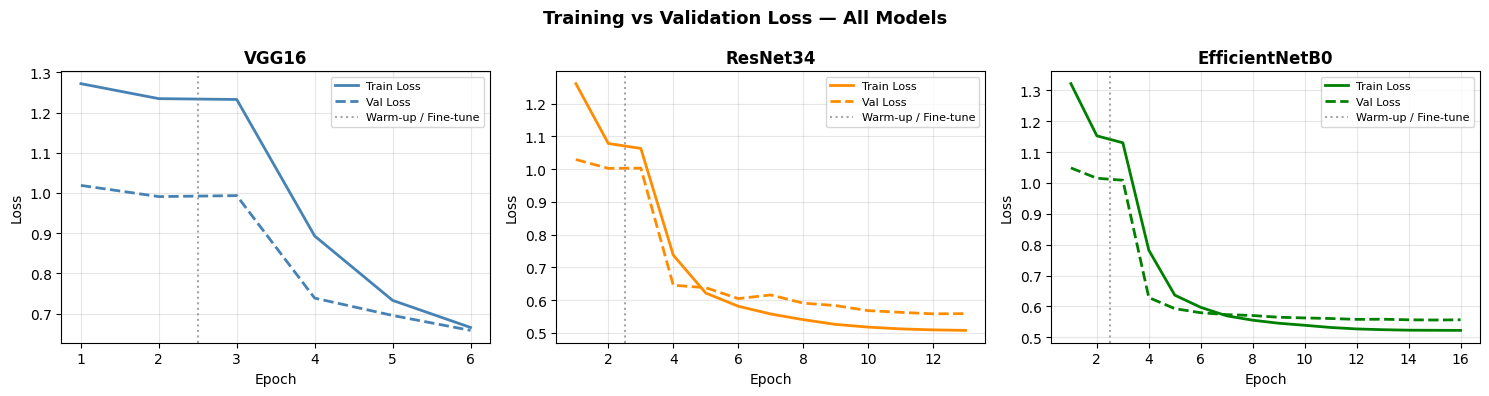

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = {'VGG16': 'steelblue', 'ResNet34': 'darkorange', 'EfficientNetB0': 'green'}

for ax, name in zip(axes, MODEL_NAMES):
    hist   = history_export[name]['history']
    epochs = range(1, len(hist['train_loss']) + 1)
    ax.plot(epochs, hist['train_loss'], label='Train Loss',
            color=colors[name], linewidth=2)
    ax.plot(epochs, hist['val_loss'],   label='Val Loss',
            color=colors[name], linewidth=2, linestyle='--')
    ax.axvline(x=WARMUP_EPOCHS + 0.5, color='grey', linestyle=':',
               alpha=0.7, label='Warm-up / Fine-tune')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Training vs Validation Loss — All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dl_training_loss.png', dpi=150)
plt.show()

### 3.9 Test Set Confusion Matrix

The confusion matrix shows per-class prediction performance of the best model
on the 10,000 test images. Rows represent true labels; columns represent predicted labels.
High off-diagonal values indicate classes that are frequently confused with one another.

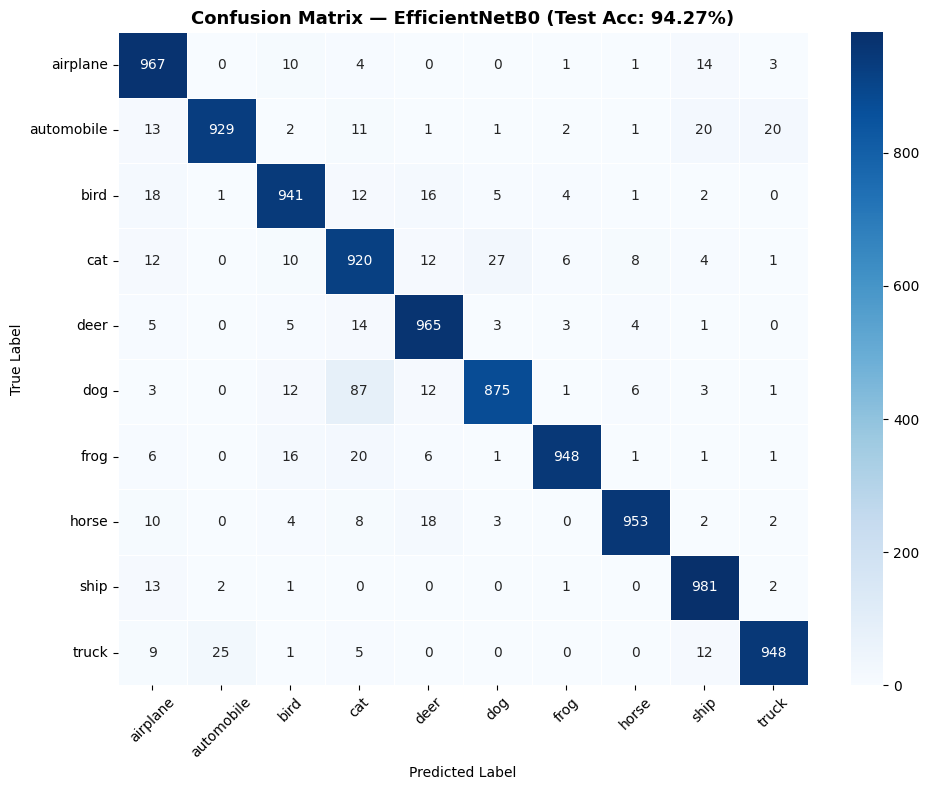

In [32]:
cm = confusion_matrix(best_labels, best_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5)
plt.title(f'Confusion Matrix — {best_name} '
          f'(Test Acc: {test_results[best_name]["test_acc"]*100:.2f}%)',
          fontsize=13, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('dl_confusion_matrix.png', dpi=150)
plt.show()

### 3.10 Sample Predictions

Ten test images are shown with their true and predicted class labels.
Green titles indicate correct predictions; red titles indicate misclassifications.
Images are un-normalised using the CIFAR-10 channel mean and standard deviation
computed in Section 2 before display.

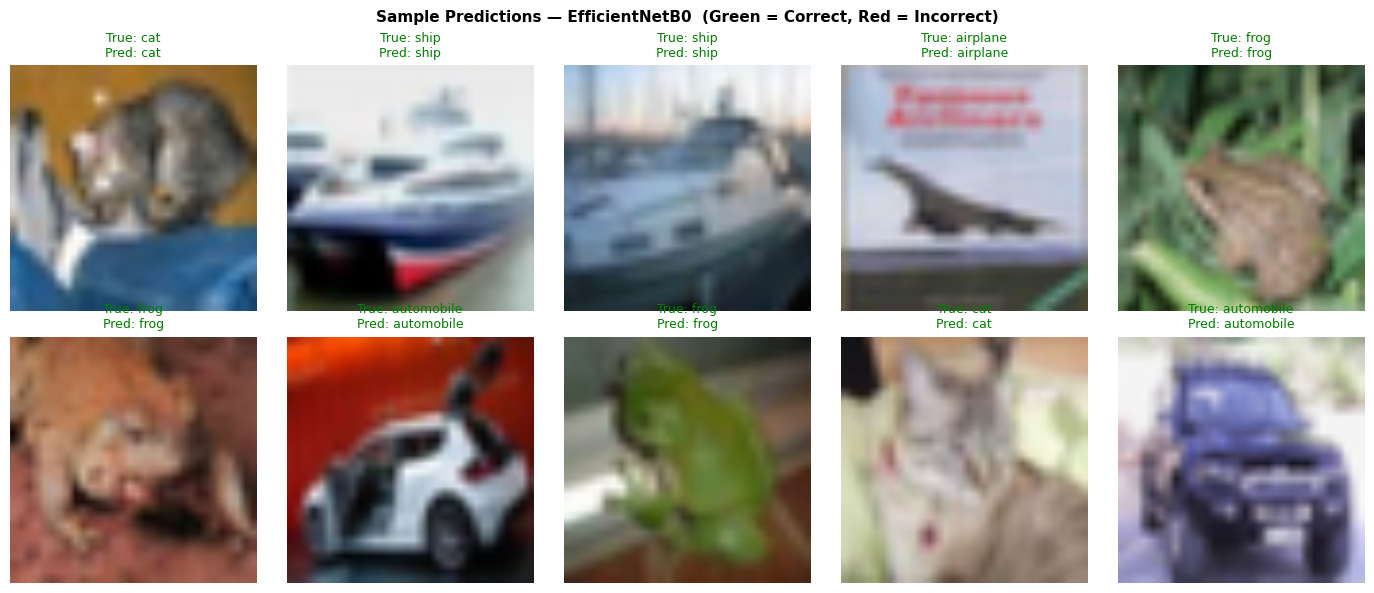

In [33]:
MEAN_t = torch.tensor(CIFAR10_MEAN).view(3, 1, 1)
STD_t  = torch.tensor(CIFAR10_STD).view(3, 1, 1)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    img_tensor, _ = test_dataset[i]
    # Un-normalise: reverse Normalize(mean, std)
    img = (img_tensor * STD_t + MEAN_t).permute(1, 2, 0).clamp(0, 1).numpy()
    true_lbl = class_names[best_labels[i]]
    pred_lbl = class_names[best_preds[i]]
    color    = 'green' if true_lbl == pred_lbl else 'red'
    ax.imshow(img)
    ax.set_title(f"True: {true_lbl}\nPred: {pred_lbl}", color=color, fontsize=9)
    ax.axis('off')

plt.suptitle(f'Sample Predictions — {best_name}  (Green = Correct, Red = Incorrect)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('dl_sample_predictions.png', dpi=150)
plt.show()

### 3.11 Deep Learning vs Machine Learning Comparison

The table and chart below compare the validation-selected Deep Learning model
against the Machine Learning model from `development_ML.ipynb`.

#### Why does Deep Learning outperform classical ML on CIFAR-10?

| Factor | Deep Learning | Machine Learning (SVM + HOG) |
|---|---|---|
| Feature learning | Automatic - convolutional layers learn hierarchical features directly from raw pixels | Manual - HOG computes hand-crafted gradient histograms |
| Spatial hierarchy | Captured via stacked conv layers (edges → textures → parts → objects) | HOG captures local gradient orientation but misses long-range structure |
| Data efficiency | Requires large datasets; compensated here by ImageNet pre-training | Can work with fewer samples; no warm-up needed |
| Training cost | High - GPU hours, millions of parameters | Low - CPU-trainable in minutes, lightweight model |
| Interpretability | Low - features are distributed across thousands of neurons | Higher - HOG descriptors are human-interpretable |

#### Expected class-level differences

- **Animals (cat, dog, deer, bird):** DL is expected to outperform ML significantly, as distinguishing fine-grained textures and shapes benefits from learned deep features. HOG struggles with pose variation and background clutter in these classes.
- **Vehicles (airplane, automobile, ship, truck):** Both models should perform reasonably well. Vehicles have consistent shapes that HOG can capture, so the gap narrows.
- **Most confused pairs:** Cat↔dog and automobile↔truck are typically the hardest for both models because of visual similarity within pairs.

#### Conclusion

Deep Learning achieves higher accuracy by learning task-specific features end-to-end,
at the cost of significantly more compute and less interpretability.
For production scenarios with limited compute or labelled data, classical ML remains a
practical alternative. The per-class chart in Section 3.11 shows exactly where each
approach gains and loses ground.

             Metric        DL (EfficientNetB0) ML (SVM + HOG + Colour Histogram)
      Test Accuracy                     94.27%                            66.13%
Feature Engineering Automatic (learned by CNN)   Manual (HOG + Colour Histogram)
      Training Time                   57.4 min                          60.3 min
         Model Size                4.0M params                       Lightweight
   Interpretability                        Low                              High



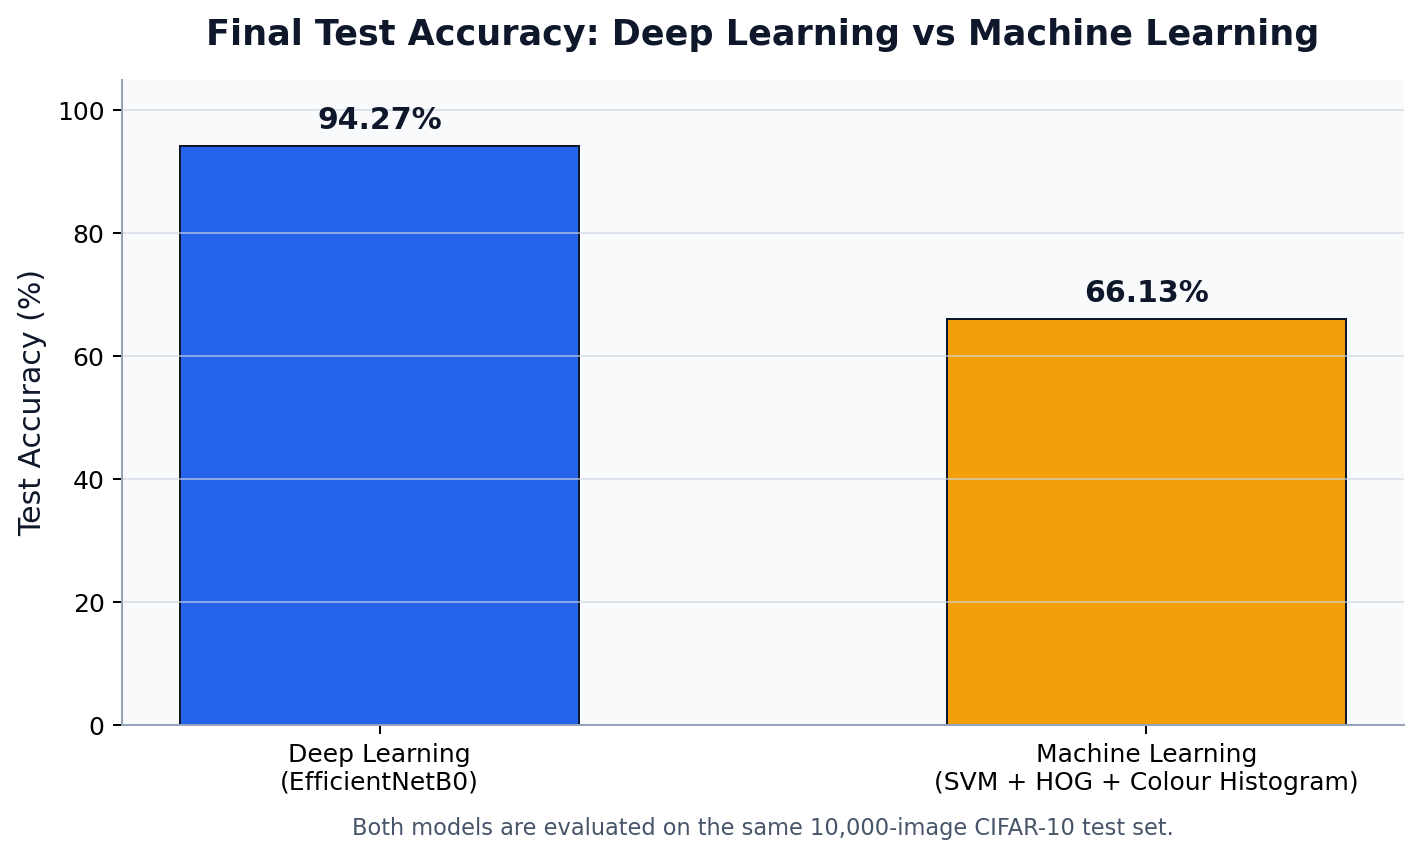

In [36]:
ml_acc        = 0.6613
ml_model_name = 'SVM + HOG + Colour Histogram'
ml_train_mins = 60.3

dl_acc    = test_results[best_name]['test_acc']
dl_params = history_export[best_name]['params_M']
dl_mins   = history_export[best_name]['train_sec'] / 60

# Create a summary table for DL vs ML comparison.
summary = pd.DataFrame({
    'Metric'               : ['Test Accuracy', 'Feature Engineering',
                              'Training Time', 'Model Size', 'Interpretability'],
    f'DL ({best_name})'    : [f'{dl_acc*100:.2f}%', 'Automatic (learned by CNN)',
                              f'{dl_mins:.1f} min', f'{dl_params:.1f}M params', 'Low'],
    f'ML ({ml_model_name})': [f'{ml_acc*100:.2f}%', 'Manual (HOG + Colour Histogram)',
                              f'{ml_train_mins} min', 'Lightweight', 'High'],
})
print(summary.to_string(index=False))
print()

# Plot final test accuracy for DL and ML using the notebook results.
fig, ax = plt.subplots(figsize=(8, 5.2), dpi=180)
fig.patch.set_facecolor('white')
ax.set_facecolor('#F8FAFC')

bars = ax.bar(
    [f'Deep Learning\n({best_name})', f'Machine Learning\n({ml_model_name})'],
    [dl_acc * 100, ml_acc * 100],
    color=['#2563EB', '#F59E0B'], edgecolor='#0F172A', linewidth=0.8, width=0.52
)

ax.set_ylabel('Test Accuracy (%)', fontsize=12, color='#0F172A')
ax.set_title('Final Test Accuracy: Deep Learning vs Machine Learning',
             fontsize=14, fontweight='bold', color='#0F172A', pad=14)
ax.set_ylim(0, 105)
ax.grid(axis='y', color='#CBD5E1', linewidth=0.7, alpha=0.7)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#94A3B8')

for bar, acc in zip(bars, [dl_acc * 100, ml_acc * 100]):
    ax.text(bar.get_x() + bar.get_width()/2, acc + 1.8,
            f'{acc:.2f}%', ha='center', va='bottom',
            fontweight='bold', fontsize=12, color='#0F172A')

ax.text(0.5, -0.17,
        'Both models are evaluated on the same 10,000-image CIFAR-10 test set.',
        transform=ax.transAxes, ha='center', fontsize=9, color='#475569')

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('dl_vs_ml_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


### 3.12 Per-Class Accuracy Comparison: DL vs ML

The chart below shows how each model performs on every individual CIFAR-10 class.
This reveals which categories benefit most from deep feature learning
and which classes remain challenging for both approaches.

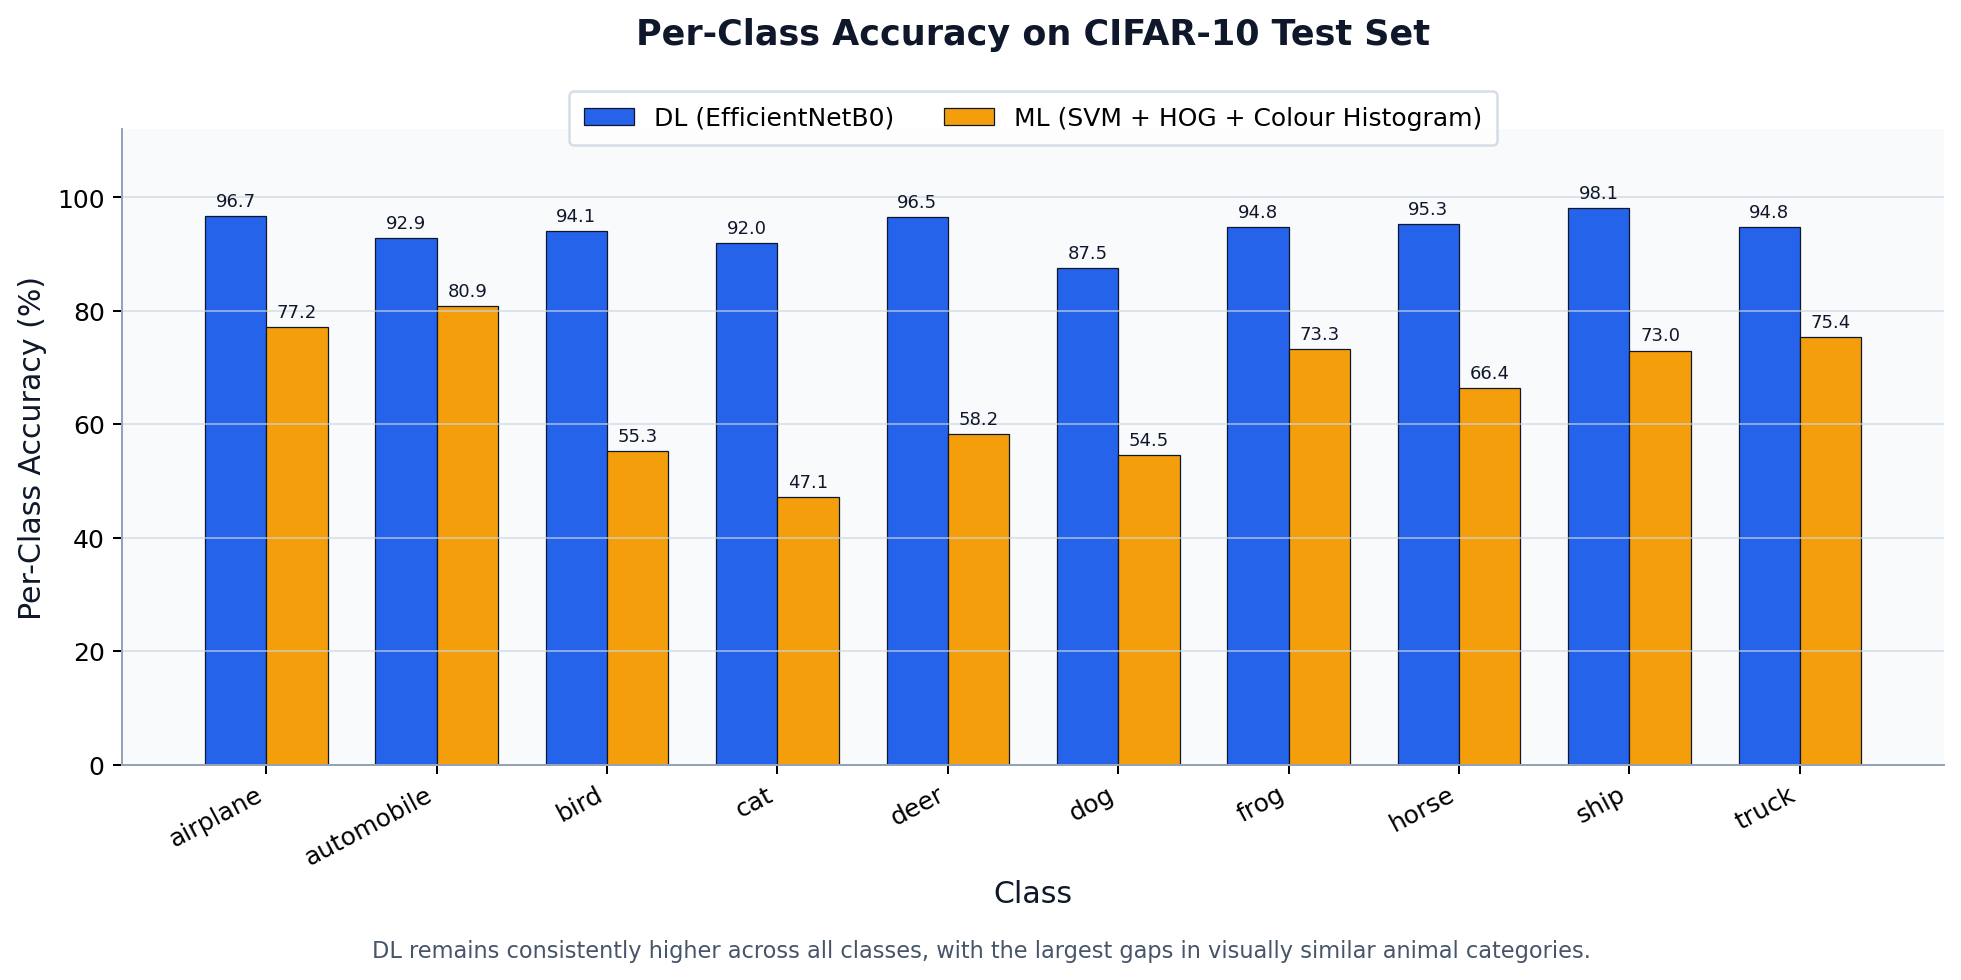

Class          DL Acc   ML Acc     Diff
------------------------------------------
airplane        96.7%    77.2% +  19.5%
automobile      92.9%    80.9% +  12.0%
bird            94.1%    55.3% +  38.8%
cat             92.0%    47.1% +  44.9%
deer            96.5%    58.2% +  38.3%
dog             87.5%    54.5% +  33.0%
frog            94.8%    73.3% +  21.5%
horse           95.3%    66.4% +  28.9%
ship            98.1%    73.0% +  25.1%
truck           94.8%    75.4% +  19.4%


In [37]:
# ML per-class accuracy from development_ML.ipynb (SVM + HOG + Colour Histogram).
# Source: Section 3.8 error_analysis_df in development_ML.ipynb, in CIFAR-10 class order
ml_class_acc = [0.772, 0.809, 0.553, 0.471, 0.582,
                0.545, 0.733, 0.664, 0.730, 0.754]

# DL per-class accuracy from the test confusion matrix.
cm_test = confusion_matrix(best_labels, best_preds)
dl_class_acc = cm_test.diagonal() / cm_test.sum(axis=1)   # recall per class

# Plot per-class accuracy for DL and ML using the notebook results.
x = np.arange(len(class_names))
width = 0.36

fig, ax = plt.subplots(figsize=(11, 6), dpi=180)
fig.patch.set_facecolor('white')
ax.set_facecolor('#F8FAFC')

bars_dl = ax.bar(x - width/2, dl_class_acc * 100, width,
                 label=f'DL ({best_name})', color='#2563EB', edgecolor='#0F172A', linewidth=0.5)
bars_ml = ax.bar(x + width/2, [v * 100 for v in ml_class_acc], width,
                 label=f'ML ({ml_model_name})', color='#F59E0B', edgecolor='#0F172A', linewidth=0.5)

ax.set_xlabel('Class', fontsize=12, color='#0F172A')
ax.set_ylabel('Per-Class Accuracy (%)', fontsize=12, color='#0F172A')
ax.set_title('Per-Class Accuracy on CIFAR-10 Test Set',
             fontsize=14, fontweight='bold', color='#0F172A', pad=34)
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=28, ha='right')
ax.set_ylim(0, 112)
ax.grid(axis='y', color='#CBD5E1', linewidth=0.7, alpha=0.7)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#94A3B8')

legend = ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.08),
                   ncol=2, frameon=True, fontsize=10, borderpad=0.6)
legend.get_frame().set_edgecolor('#CBD5E1')
legend.get_frame().set_facecolor('white')

# Annotate each bar with its value.
for bar in list(bars_dl) + list(bars_ml):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 1.0,
            f'{h:.1f}', ha='center', va='bottom', fontsize=7.2, color='#0F172A')

fig.text(0.5, 0.015,
         'DL remains consistently higher across all classes, with the largest gaps in visually similar animal categories.',
         ha='center', fontsize=9, color='#475569')

plt.tight_layout(rect=[0, 0.035, 1, 0.91])
plt.savefig('dl_vs_ml_perclass.png', dpi=300, bbox_inches='tight')
plt.show()

# Display the numeric per-class comparison.
print(f"{'Class':<12} {'DL Acc':>8} {'ML Acc':>8} {'Diff':>8}")
print('-' * 42)
for cls, dl_a, ml_a in zip(class_names, dl_class_acc, ml_class_acc):
    diff = (dl_a - ml_a) * 100
    sign = '+' if diff >= 0 else ''
    print(f"{cls:<12} {dl_a*100:>7.1f}% {ml_a*100:>7.1f}% {sign}{diff:>6.1f}%")